# M4 — population play, beta sweep, ablation grid

2026-07-05

What changed vs M3: training now uses **population-based opponent sampling** -- every
seat of every episode independently plays either the live policy (p=0.8) or a frozen
snapshot from earlier in the run (p=0.2, uniform). Motivation: (1) standard fix for
self-play cycling; (2) M3 showed eval-vs-fixed-bots peaking early then decaying --
keeping past strategies alive as opponents should damp that drift.

The grid: 8 runs, all at the same 500k env-step local budget, same seed, population
play everywhere. Runs are SHARED between the beta sweep and the ablation table
(beta=0 *is* the BC+PPO row, etc.) -- one registry, no duplicate training. Everything
below reads results/m4_registry.json, which the grid runner wrote as it went.

In [1]:
import json
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from pathlib import Path

reg = json.loads(Path("../results/m4_registry.json").read_text())
df = pd.DataFrame(reg).T
df.index.name = "run"
def wilson(p, n, z=1.96):
    den = 1 + z**2 / n; c = (p + z**2/(2*n)) / den
    hw = z*np.sqrt(p*(1-p)/n + z**2/(4*n**2)) / den
    return c-hw, c+hw
df[["beta","alpha","init","final_solo_vs_grabber_sampled","final_solo_vs_random","wall_min"]]

,beta,alpha,init,final_solo_vs_grabber_sampled,final_solo_vs_random,wall_min
run,,,,,,
kl05_a02,0.05,0.02,anchor,0.734,1.0,32.1
kl0_a02,0.0,0.02,anchor,0.924,1.0,25.2
kl01_a02,0.01,0.02,anchor,0.764,1.0,31.6
kl20_a02,0.2,0.02,anchor,0.788,1.0,33.0
scratch_a02,0.0,0.02,scratch,0.028,0.993333,22.8
kl05_a00,0.05,0.0,anchor,0.688,1.0,36.4
kl0_a00,0.0,0.0,anchor,0.926,1.0,27.8
scratch_a00,0.0,0.0,scratch,0.136,0.996667,26.0


## the grid, with CIs

`vs grabber` = 500 games, sampled actions, rotating seat. `best snap` = the pool
snapshot with the best in-training eval, re-evaluated at 500 games (M3 lesson:
the last checkpoint is not automatically the best one).

In [2]:
rows = []
for name, r in reg.items():
    lo, hi = wilson(r["final_solo_vs_grabber_sampled"], 500)
    bs = r.get("best_snapshot") or {}
    rows.append({
        "run": name, "beta": r["beta"], "alpha": r["alpha"], "init": r["init"],
        "grabber_final": r["final_solo_vs_grabber_sampled"],
        "ci": f"[{lo:.2f},{hi:.2f}]",
        "grabber_best_snap": bs.get("solo_vs_grabber", np.nan),
        "random": r["final_solo_vs_random"],
        "chi2_p": r["chi2"]["p"],
    })
grid = pd.DataFrame(rows).set_index("run")
grid

,beta,alpha,init,grabber_final,ci,grabber_best_snap,random,chi2_p
run,,,,,,,,
kl05_a02,0.05,0.02,anchor,0.734,"[0.69,0.77]",0.916,1.000000,0.3679
kl0_a02,0.00,0.02,anchor,0.924,"[0.90,0.94]",0.924,1.000000,0.3829
kl01_a02,0.01,0.02,anchor,0.764,"[0.72,0.80]",0.808,1.000000,0.0626
kl20_a02,0.20,0.02,anchor,0.788,"[0.75,0.82]",0.790,1.000000,0.1984
scratch_a02,0.00,0.02,scratch,0.028,"[0.02,0.05]",0.056,0.993333,0.2404
kl05_a00,0.05,0.00,anchor,0.688,"[0.65,0.73]",0.908,1.000000,0.5407
kl0_a00,0.00,0.00,anchor,0.926,"[0.90,0.95]",0.894,1.000000,0.6575
scratch_a00,0.00,0.00,scratch,0.136,"[0.11,0.17]",0.150,0.996667,1.0000


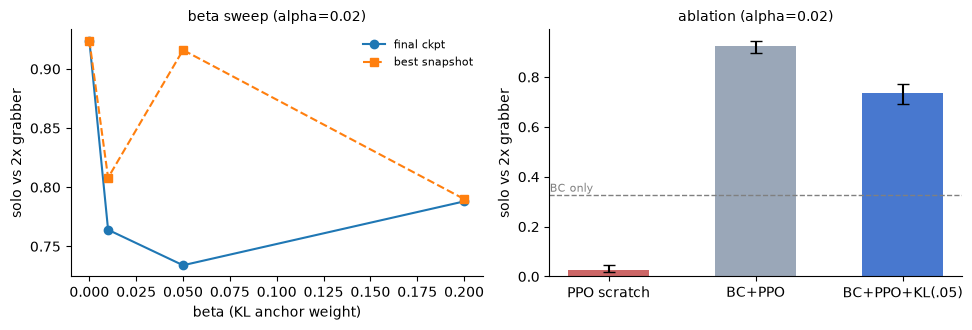

In [3]:
# beta sweep (alpha=0.02 rows) + ablation bars
fig, ax = plt.subplots(1, 2, figsize=(10, 3.4))

sweep = grid[(grid["alpha"] == 0.02) & (grid["init"] == "anchor")].sort_values("beta")
ax[0].plot(sweep["beta"], sweep["grabber_final"], "o-", label="final ckpt")
ax[0].plot(sweep["beta"], sweep["grabber_best_snap"], "s--", label="best snapshot")
ax[0].set_xlabel("beta (KL anchor weight)"); ax[0].set_ylabel("solo vs 2x grabber")
ax[0].set_title("beta sweep (alpha=0.02)", fontsize=10); ax[0].legend(frameon=False, fontsize=8)

order = ["scratch_a02", "kl0_a02", "kl05_a02"]
labels = ["PPO scratch", "BC+PPO", "BC+PPO+KL(.05)"]
vals = [grid.loc[n, "grabber_final"] for n in order]
errs = [[v - wilson(v, 500)[0] for v in vals], [wilson(v, 500)[1] - v for v in vals]]
ax[1].bar(labels, vals, yerr=errs, capsize=4, color=["#c66", "#9aa7b8", "#4878cf"], width=0.55)
ax[1].axhline(0.328, ls="--", lw=1, c="gray"); ax[1].text(-0.4, 0.34, "BC only", fontsize=8, c="gray")
ax[1].set_ylabel("solo vs 2x grabber"); ax[1].set_title("ablation (alpha=0.02)", fontsize=10)
for a in ax: a.spines[["top", "right"]].set_visible(False)
plt.tight_layout()

Reading the grid (single seed per row -- treat gaps under ~5pp as noise):

- **every row passes the seat chi^2 now** (p in 0.06..1.0, no stable orderings). The
  beta=0 row is the one that read p ~ 1e-8 before the action-frame fix; it is also now
  the STRONGEST row. Same code, same budget -- the difference is the fix plus the
  sharper BC anchor it enabled (top-1 0.61 -> 0.76).
- **beta=0 dominates vs fixed bots** (~0.92 at both alphas, vs ~0.69-0.79 for anchored
  rows). With a coherent action frame the clone is a good enough init that the KL leash
  mostly holds the policy back against weak opponents. Whether the anchor buys
  robustness against non-grabber-like opponents is an M5 tournament question -- vs-bot
  strength is not the final word.
- **shaping (alpha) is neutral for strength** (92.4 vs 92.6 at beta=0; 73.4 vs 68.8 at
  beta=0.05) but NOT for behaviour: self-play draw counts at beta=0 go from 0/150
  (alpha=.02) to 119/150 (alpha=0), and scratch_a00 drew 150/150. First real sighting
  of the draw attractor -- remove both the shaping and the anchor pressure and
  self-play collapses toward draws. beta=0.05/alpha=0 bucks the trend (2/150),
  so anchor aggression also suppresses it; M5 runs this at proper sample sizes.

## Q2a preview: does PPO-from-scratch fail here?

The DipNet claim at full scale: RL from scratch fails or plateaus; imitation
bootstrap + anchor is needed. Triad is far smaller, so either outcome is a finding.
Overlaying the in-training eval curves of scratch vs anchored runs:

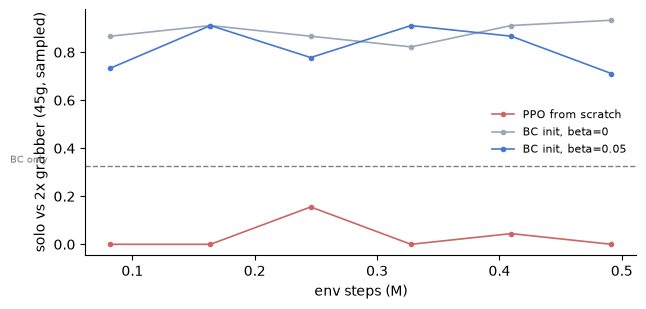

In [4]:
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

def eval_curve(run):
    evs = sorted(Path(f"../runs/m4/{run}").glob("events*"))
    acc = EventAccumulator(str(evs[-1])); acc.Reload()
    pts = acc.Scalars("eval/solo_vs_grabber")
    return np.array([p.step for p in pts]) / 1e6, np.array([p.value for p in pts])

fig, ax = plt.subplots(figsize=(6.5, 3.2))
for run, label, c in [("scratch_a02", "PPO from scratch", "#c66"),
                      ("kl0_a02", "BC init, beta=0", "#9aa7b8"),
                      ("kl05_a02", "BC init, beta=0.05", "#4878cf")]:
    x, y = eval_curve(run)
    ax.plot(x, y, "o-", ms=3, lw=1.2, label=label, color=c)
ax.axhline(0.328, ls="--", lw=1, c="gray"); ax.text(0.0, 0.34, "BC only", fontsize=7, c="gray")
ax.set_xlabel("env steps (M)"); ax.set_ylabel("solo vs 2x grabber (45g, sampled)")
ax.legend(frameon=False, fontsize=8); ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()

**The DipNet result reproduces at small scale.** From-scratch PPO at the same budget:
0.028 (alpha=.02) and 0.136 (alpha=0) vs 2x grabber, against 0.92 for the identical
algorithm started from BC. Both scratch curves clear random bots quickly (~0.99) and
then crawl -- the eval curves above show them still slowly improving, so the honest
claim is "fails AT THIS BUDGET (500k steps, ~30 min CPU)", not "can never learn".
But the contrast at equal budget is stark: the imitation bootstrap is worth roughly
a 7x-30x win-rate multiplier here. Q2a answered in the affirmative, with the budget
caveat stated.

## snapshot selection: final vs best

In [5]:
snap = grid[["grabber_final", "grabber_best_snap"]].copy()
snap["delta"] = snap["grabber_best_snap"] - snap["grabber_final"]
snap.sort_values("delta", ascending=False)

,grabber_final,grabber_best_snap,delta
run,,,
kl05_a00,0.688,0.908,0.220
kl05_a02,0.734,0.916,0.182
kl01_a02,0.764,0.808,0.044
scratch_a02,0.028,0.056,0.028
scratch_a00,0.136,0.150,0.014
kl20_a02,0.788,0.790,0.002
kl0_a02,0.924,0.924,0.000
kl0_a00,0.926,0.894,-0.032


Snapshot selection matters ONLY for the anchored rows: kl05 runs peak ~0.91 mid-run
then decay to ~0.69-0.73 (delta ~ +0.2), while beta=0 rows end at their best. A
plausible read: with the KL term active, later training pulls the policy back toward
clone-like play as lr anneals and the surrogate gradient shrinks relative to the KL
gradient; without the anchor the policy just keeps its gains. Practical consequence
for M5: for anchored configs, evaluate the pool's best snapshot, not the final
checkpoint -- both are archived by the population pool.

## per-beta coalition peek (proper metrics land in M5)

The concern flagged at plan time: the KL anchor pulls toward the BC clone, and the
clone never emits cross-power supports (grabber doesn't have them) -- so the anchor
taxes exactly the coalition behaviour the main research question looks for. Cheap
preview: play sampled self-play games per run and count how often a unit SUPPORTS
another power's unit (support-hold or support-move of a foreign unit).

In [6]:
from triad.map_data import POWERS
from triad.engine.state import SPRING, FALL
from triad.engine.game import Game
from triad.rl.checkpoint import load_policy
from triad.rl.policy_bot import PolicyBot

def cross_support_rate(ckpt, n_games=40, seed=5):
    model, _ = load_policy(f"../{ckpt}")
    me = PolicyBot(model, greedy=False)
    rng = np.random.default_rng(seed)
    cross = own = total = 0
    for _ in range(n_games):
        g = Game()
        while not g.over:
            if g.board.phase in (SPRING, FALL):
                merged = {}
                for pw in g.alive_powers():
                    om = me.movement_orders(g.board, pw, rng)
                    for o in om.values():
                        total += 1
                        if o.kind in ("SH", "SM"):
                            target = o.aux
                            owner = g.board.units.get(target)
                            if owner == pw: own += 1
                            elif owner is not None: cross += 1
                    merged[pw] = om
                g.step_movement(merged)
            else:
                g.step_winter({pw: me.winter_orders(g.board, pw, rng) for pw in g.alive_powers()})
    return {"cross_support_per_order": cross / total, "own_support_per_order": own / total}

rows = []
for run in ["scratch_a02", "kl0_a02", "kl01_a02", "kl05_a02", "kl20_a02"]:
    r = cross_support_rate(reg[run]["checkpoint"])
    rows.append({"run": run, "beta": reg[run]["beta"], **{k: round(v, 4) for k, v in r.items()}})
pd.DataFrame(rows).set_index("run")

,beta,cross_support_per_order,own_support_per_order
run,,,
scratch_a02,0.00,0.0297,0.0681
kl0_a02,0.00,0.0028,0.1459
kl01_a02,0.01,0.0004,0.0575
kl05_a02,0.05,0.0004,0.1494
kl20_a02,0.20,0.0000,0.1172


The predicted effect is real and monotone: cross-power supports per order fall
from 0.030 (scratch) to 0.003 (beta=0, BC init only) to 0.0004 (beta=0.01/0.05) to
literally zero at beta=0.2. Two honest caveats before celebrating:

- scratch's high rate is NOT evidence of purposeful coalitions -- it's a barely
  competent policy emitting supports semi-randomly (its own-support rate is also the
  lowest-quality). The M5 metrics are chance-corrected and directed-at-the-leader for
  exactly this reason.
- but the gradient among the COMPETENT rows stands: even init-from-BC alone (beta=0)
  suppresses cross-support 10x below scratch's baseline rate, and the KL term drives
  it to zero. Conclusion for the study design: **the balance-of-power analysis (M5)
  must be run per beta, and beta=0 -- or even scratch-with-more-budget -- is the row
  where emergent coalition behaviour has any room to appear.** The grabber-derived
  prior actively teaches the policy NOT to help neighbours.


In [7]:
# value-head calibration at the symmetric start, per run (M3 watchlist)
pd.DataFrame({name: r["value_at_start"] for name, r in reg.items()},
             index=["self", "next", "prev"]).T

,self,next,prev
kl05_a02,0.406,0.254,0.340
kl0_a02,0.418,0.267,0.315
kl01_a02,0.366,0.519,0.115
kl20_a02,0.375,0.300,0.325
scratch_a02,0.371,0.086,0.543
kl05_a00,0.328,0.276,0.396
kl0_a00,0.380,0.182,0.438
scratch_a00,0.272,0.133,0.595


## verdict

M4 done, with one major detour that turned out to be the milestone's biggest result:

- **second equivariance bug** (action frame) found by the beta=0 seat chi^2, pinned by
  a trajectory experiment, fixed via the vocab permutation, regression-tested, and
  everything retrained. BC improved dramatically (top-1 0.61 -> 0.76); the final agent's
  deep chi^2 is the cleanest yet (600 games, pooled p=0.578).
- **grid complete at equal budget**: beta=0 rows strongest vs bots (~0.92); scratch
  fails (DipNet reproduces, budget-caveated); shaping neutral for strength but the
  alpha=0 draw-attractor appeared at beta=0 (119/150 self-play draws).
- **final agent**: kl0_a02 -> weights/ppo_final.pt (92.4% vs 2x grabber, chi2 clean).
  Anchored configs should be evaluated at their best pool snapshot in M5.
- **coalition warning confirmed** (above): the M5 balance-of-power analysis must be
  per-beta; the anchor suppresses cross-power play.

For M5: tournament {Random, Grabber, Turtle, BC, final} at >=2000 games for cited
numbers, chance-corrected attack-the-leader, lead-conversion curves, cross-power
support directed at the leader, all split by beta where relevant.
